# Building a Transformer from Scratch

> ↩ **Previous in the series:** [Language Modeling with Embeddings — an MLP](embeddings.ipynb)


This notebook builds a GPT — the architecture behind ChatGPT — one idea at a time, in PyTorch. It's the direct sequel to the [embeddings notebook](embeddings.ipynb), and it picks up exactly where that one stopped.

### Where we left off — and the wall we hit

The embeddings notebook built a real language model: it turned each character into a learned vector with an **embedding** table, concatenated the last 8 of those vectors, and ran them through an MLP to predict the next character. Trained with **cross-entropy** on this same Shakespeare corpus, it reached a validation loss of **~2.0** — comfortably below a bigram's **~2.5**, still short of the **~1.7** a full GPT reaches.

It also hit a wall and named it precisely (its Step 9). The MLP's view of the past is *fixed and blunt*: every one of the 8 context slots owns private weights, the parameter count grows with the window, and — the part attention fixes — each slot is weighted by its *position*, never by its *content*. The character two-back gets the same treatment whether it's a stray comma or the colon that ends a speaker's name. **This notebook replaces that concatenate-and-MLP middle with attention** — the mechanism that lets each position decide, from content, how much of every earlier position to pull in.

Three things carry straight over from the previous notebooks, so we lean on them instead of rebuilding them from scratch:

- **PyTorch is the autograd engine we built by hand, batched.** The neural-net notebook's `Value` class wrapped a single number and recorded every `+` and `*` so `backward()` could fill in every `.grad`. The embeddings notebook then verified, gradient-for-gradient on `(a + b) * b`, that a PyTorch tensor is that *same* machine wrapping an array. So `loss.backward()` here does exactly what it did in both earlier notebooks — we take that as settled and won't re-derive it.
- **The tokenizer, the data split, and the embedding table** — same `input.txt`, same 65-character vocabulary, same `stoi`/`itos`, same idea of a learned lookup table. We set them up again in a few cells (so this notebook stands on its own), but they should read as review, not new material.
- **Softmax, cross-entropy, sampling, and the `-log(1/65) ≈ 4.17` untrained-loss check** — all introduced in the embeddings notebook (its Step 6); all reused here on every model. We recall them in one callout rather than re-deriving them.

Because so much carries over, we don't restart from zero. A short **setup** section establishes the data and tokenizer — all review — and then **Step 1** builds a baseline model plus the one piece of new PyTorch machinery (`nn.Module`) that the rest of the notebook is built from. The genuinely new ideas begin in Step 2, with attention.

### The one job: predict the next character

Everything here serves a single task: **given some text, predict the character that comes next.** Feed in `First Citizen`, and a good model puts high probability on `:` or a space, low probability on `q`. That's it. It sounds almost too simple to be interesting, but this one capability, repeated, *is* text generation: predict a character, append it, feed the longer string back in, predict again. Do that a few hundred times and you've written a paragraph. ChatGPT is the same loop at enormous scale (predicting word-pieces instead of characters).

So the model is a function `f(context) → a score for every possible next character`. Training adjusts its parameters until those scores are good. The neural-net notebook's four-step loop — **predict, score, assign blame (backprop), nudge** — is still the entire training story; only the model in the middle changes.

### The through-line: how much context can the model use?

Every step in this notebook is an answer to one question: **when predicting the next character, how much of the earlier text is the model allowed to use, and how well?**

- **Step 1** — a **bigram** baseline that uses *only the single current character*, wrapped in the `nn.Module` machinery every later model reuses. `e` predicts the next char the same way whether it's in `the` or `she`. It's the true zero of the context axis — weaker even than the previous notebook's MLP — and it exists to be beaten.
- **Steps 2–4** — we invent **attention**: a way for each position to look back at earlier positions and pull in what's relevant. First with fixed equal weighting (a plain average), then with weights the model *learns*, then with several such lookups running in parallel.
- **Steps 5–6** — we give the model room to *think* about what it gathered (a small per-position network), and the plumbing (residual connections, normalization) that lets us stack these pieces deep without training falling apart.
- **Step 7** — we stack it all four layers deep, scale up, and get recognizable Shakespeare.

We train each model on the same data and print its **loss** — a single number measuring how wrong its predictions are, lower is better — so you can watch each idea pay off (or, in Step 2, deliberately backfire).

| Step | Model | Key addition | Context it can use |
|------|-------|-------------|--------------------|
| 1 | Bigram (baseline) | `nn.Module` + embedding lookup | Just the current character |
| 2 | Uniform Attention | Averaging previous tokens via matrix multiply | All previous, weighted equally |
| 3 | Self-Attention | Learned queries, keys, and values | All previous, weighted by relevance |
| 4 | Multi-Head Attention | Several attention lookups in parallel | Multiple relevance patterns at once |
| 5 | + Feed-Forward | Per-token network after attention | (adds nonlinear reasoning) |
| 6 | + Residual + LayerNorm | Skip connections + normalization | (makes depth trainable) |
| 7 | **Full GPT** | Stacked layers, dropout, scaled up | 32 characters, 4 layers deep |

Keep the previous notebook's MLP in view as the number to beat. At **~2.0** it already outscores *every single-block model here* — Steps 1 through 6 alike. That is not a mistake in our steps — a lone attention head is a *weaker* per-position computation than the MLP's wide hidden layer. Attention's payoff shows up only in Step 7, when we stack blocks deep and scale up: the win comes from **depth** and from learning *what* to attend to, not from a single head. Watching the loss sit *above* 2.0 through Steps 1–6 and then drop below it in Step 7 is the real story of the notebook.

> **A note for this audience.** This notebook assumes you're comfortable with math and code but *not* with statistics or machine learning. A few ideas here rest on probability — softmax, cross-entropy, sampling, variance — and each is introduced from scratch, in plain terms, right before it's first used. Watch for the `>` callout boxes: they flag naming traps and conventions that are "obvious" only to people who already do this.

We need PyTorch for the models, and matplotlib to plot loss curves and attention maps. We also fix the random seed so every run of this notebook produces the same numbers — the same weight initializations and the same random batches — which makes the losses quoted in the text reproducible.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1337)  # reproducible weights + batches (1337 is Karpathy's traditional seed)

## Data

We load `input.txt` — the [tiny Shakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt) dataset (~1.1 MB of Shakespeare plays). This is our entire training corpus.

In [8]:
text = open('input.txt', 'r').read()
print(f'{len(text)} characters')
print(text[:200])

1115394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


### Tokenizer

Same job, same tool as the embeddings notebook: a network only does arithmetic on numbers, so the first step is turning text into integer IDs. A **token** is the smallest unit the model reads — here, one character. `stoi` ("string to int") maps each distinct character to an ID and `itos` maps back; `encode` turns a string into a list of IDs, `decode` turns IDs back into a string. This is character-for-character the tokenizer from the previous notebook — same `input.txt`, same 65 characters — so we rebuild it in a single cell and move on.

With 65 distinct characters our **vocabulary** (the full set of tokens the model knows) has size 65. Real models use *subword* tokenizers where a token is a common chunk like `ing` or `the`, giving vocabularies of 50k+ — but the principle is identical: text ↔ integers. (The [tokenizer notebook](tokenizer.ipynb) later in the series builds one of those from scratch.)

> **"Token" vs "character".** In this notebook a token *is* a character, so the words are interchangeable. Keep the distinction in mind only because in production LLMs a token is usually a word-piece, not a single letter.

In [9]:
chars = sorted(set(text))
vocab_size = len(chars)
print(f'Vocab size: {vocab_size}')
print(''.join(chars))

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

Vocab size: 65

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


### Train/Val Split

We encode the entire text into a tensor of integers, then split 90/10: the first 90% is the **training set** (what the model learns from), the held-back 10% is the **validation set** — text the model *never trains on*. Why keep some aside? A model can score well on its training text just by memorizing it. Loss measured on unseen text is the honest test of whether it learned general patterns, so every "how good is this model really?" number in this notebook comes from the validation set. No shuffling — we just cut the text at the 90% mark.

In [10]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f'Train: {len(train_data)} tokens, Val: {len(val_data)} tokens')

Train: 1003854 tokens, Val: 111540 tokens


### Batching: inputs, targets, and the `B, T` shapes

To train, we need examples of the form "here's some context → here's the correct next character." As in the embeddings notebook, we manufacture them from the text itself — sliding a window over the corpus, no hand-labeling required. But we do it in a sharper way here, and the difference is exactly the limitation the previous notebook flagged.

The embeddings MLP built *one* training example per window: 8 characters in, the single 9th character as the target. Its Step 9 "wall" called this out — the MLP "has no mechanism for predicting at every position along the way." The transformer does. We take a chunk of `block_size` characters as the **input**, and the *same chunk shifted one character to the right* as the **target**, so *every* position carries its own answer: position 0 predicts character 1, position 1 predicts character 2, and so on down the chunk. A single length-`T` chunk is now `T` training examples at once. That one-character shift is the entire supervision signal.

`get_batch` grabs `batch_size` such chunks from random spots and stacks them, so the model trains on many examples at once (faster, and the averaged gradient is steadier).

> **Naming trap: `x` and `y`.** By long-standing ML convention, `x` (often capital `X`) holds the **inputs** and `y` holds the **targets/labels** — the correct answers. Here `y` is *not* a coordinate or a second data column; it's literally "the next character we want the model to predict." Read `xb`/`yb` as "the input batch" and "the answer batch."

> **Two shape letters, for now: `B` and `T`.** You already met these letters in the embeddings notebook, where an embedded batch printed as `B, T, C = 4, 8, 10`. Here we lean on them throughout. The batch tensors `xb` and `yb` have shape `(B, T)`:
> - **`B` = batch** — how many independent sequences we process at once (`batch_size`, here 32).
> - **`T` = time** — position within a sequence, i.e. which character slot (`block_size`, here 8). It's called "time" because the characters arrive in order, one after another.
>
> So `xb` is `B` sequences of `T` integer token IDs each. The third axis — `C` — joins them the moment each token ID becomes a *vector* of numbers, which first happens in the baseline model below. We reintroduce it there, where it actually has something to point at.

In [14]:
block_size = 8
batch_size = 32

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print(f'x shape: {xb.shape}, y shape: {yb.shape}')

# List of decoded strings (one string per batch item) - notice how y is one char off
print(f'x chars: {[decode(x.tolist()) for x in xb]}')
print(f'y chars: {[decode(y.tolist()) for y in yb]}')

x shape: torch.Size([32, 8]), y shape: torch.Size([32, 8])
x chars: ['s, here ', 'erjured,', ' matter ', 'swer it,', 'on\nBut o', 'ou wilt ', 's, the e', 'y simple', ' I will ', 'ce what ', 'y my glo', "let's re", ' ben ven', 'e and\nFr', ' to merc', 'refore w', 't, west,', 'V:\nWhere', 'e duke t', '\nRICHMON', 'f marria', 'rthy gai', 'e,\nThat ', '\nI hope ', 'd nor ba', 'is princ', '.\n\nSheph', 've done.', '?\n\nTRANI', 'u did no', 'Where it', ':\nWhy, s']
y chars: [', here i', 'rjured,\n', 'matter w', 'wer it,\n', 'n\nBut on', 'u wilt c', ', the ex', ' simple ', 'I will h', 'e what I', ' my glor', "et's ret", 'ben venu', ' and\nFro', 'to mercy', 'efore we', ', west, ', ":\nWhere'", ' duke ta', 'RICHMOND', ' marriag', 'thy gain', ',\nThat i', 'I hope t', ' nor bad', 's prince', '\n\nShephe', 'e done.\n', '\n\nTRANIO', ' did not', 'here it ', '\nWhy, si']


## Step 1: A baseline model — and the `nn.Module` idiom

Before the first real idea (attention, next), we put two things in place: a **baseline** to measure everything against, and the one piece of PyTorch machinery the rest of the notebook is built from. We get both at once by building the simplest possible next-character model.

**What's actually new here.** In the neural-net and embeddings notebooks you managed parameters *by hand* — a list of tensors, a `forward` written inline, `p.data -= lr * p.grad` to update. That was the whole point there: nothing hidden. It doesn't scale to a dozen stacked sub-layers, so from here on we use PyTorch's standard packaging:

- **`nn.Module`** — a base class that holds parameters and a `forward()`. Any `nn.Embedding` or `nn.Linear` you assign to `self` registers its weights automatically, so `model.parameters()` gathers them for the optimizer — no more hand-kept lists.
- **`nn.Embedding`** — the embedding *table* from the last notebook, wrapped as a module. `nn.Embedding(65, 65)` is a `65×65` lookup you index with token IDs — the same operation as indexing the `C` tensor there.
- **`AdamW`** — the optimizer. It runs the same *nudge* step (`param -= lr · grad`) but adapts the step size per parameter; `optimizer.step()` and `optimizer.zero_grad()` replace the manual update and grad-reset. (The embeddings notebook promised this notebook would adopt it — here it is.)

**The baseline itself: a bigram.** The model we wrap in that machinery is deliberately the weakest in the notebook — it predicts the next character from the **current character alone**. "Bigram" means pairs of adjacent characters: for each character, learn what tends to follow it. The entire model is one `nn.Embedding(65, 65)` table — row `i` holds 65 scores, one per possible next character given that the current one is `i`. Predicting after `e` (say ID 43) is a pure lookup: return row 43, and its largest entry is the most likely next character.

You already know this model is weak: it's the ~2.5 floor the embeddings notebook quoted, and that notebook's MLP — with 8 characters of context — already beat it at ~2.0. We start *below* where we left off on purpose. The bigram sees only the current character, so it is the true zero of our "how much context?" axis: `e` makes the identical prediction in `the` and in `she`, with no way to know what came before. Lifting exactly that restriction is what every step from Step 2 on does, and the bigram is the number they're measured against.

> **The third shape letter: `C` = channels.** Now `C` has a referent. When this model runs, its output has shape `(B, T, C)`: for every sequence (`B`) and position (`T`) it emits a **vector of `C` numbers** — here `C = 65`, the score for each possible next character. So `C` is simply the length of the per-position vector. It goes by several names — *channels*, *features*, or the *embedding dimension* (`n_embd`); "channels" is borrowed from images, where each pixel carries 3 numbers (its red/green/blue channels). And it isn't a constant: it's 65 at these logits, becomes 32 in Step 2's embedding space, and 64 in the full GPT. Watch for `B, T, C = logits.shape` in the code below — it destructures exactly these three axes.

> **What is a "logit"?** The 65 raw scores the table returns are called **logits**. A logit is just an unbounded real number — it can be negative, zero, or large — and *bigger means more likely*. Logits are not yet probabilities (they don't sum to 1, and negatives aren't "chances"). Turning logits into probabilities is softmax's job. The term is standard everywhere in ML; read it as "raw, pre-probability score."

One mechanical detail about the loss changes now that every position makes a prediction — it's the only genuinely new thing about scoring here — so the next cell covers it before the code.

### Scoring and sampling: what carries over, and the one new piece

Everything this baseline needs in order to train and generate, you already built in the embeddings notebook — so we recall it rather than re-derive it:

- **Softmax** turns a row of raw **logits** into a probability distribution (exponentiate, then divide by the total). **Cross-entropy** scores a prediction as `-log(probability assigned to the correct next character)`; an *untrained* model spreads probability evenly over 65 characters, so its loss starts near `-log(1/65) ≈ 4.17` — the same sanity anchor as before. `F.cross_entropy` takes **raw logits** and applies softmax internally, so `forward` never calls softmax during training; we only call `F.softmax` explicitly during generation, where we need the probabilities in hand.
- **Sampling** picks the next character from that distribution with `torch.multinomial` (each character drawn in proportion to its probability) — this randomness is what makes generation varied. The alternative, always taking the **argmax** (single most likely character), is deterministic and gets stuck in short loops; the generate-before cell shows both side by side.

**The one new piece — scoring *every* position at once.** The embeddings MLP made a single prediction per window, so its loss compared one logit-vector to one target. Here the model emits logits at *every* position — shape `(B, T, C)` — and the targets are the shifted `(B, T)` batch, so cross-entropy must score `B×T` predictions in one call. We flatten both to a flat list of positions with `.view(B*T, C)` and `.view(B*T)` before handing them to `F.cross_entropy`. That flatten is the per-position supervision from the batching section made concrete — exactly the ability the embeddings "wall" said the MLP lacked.

In [15]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # A 65x65 lookup table: row i = the logits for "what comes after character i".
        # nn.Embedding is exactly a table you index into with integer IDs.
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx is (B, T) — a batch of B sequences, each T characters long (raw integer IDs).
        # Indexing the table with every ID looks up a 65-vector per position → (B, T, 65) logits.
        logits = self.token_embedding_table(idx)   # (B, T, C) with C = vocab_size = 65

        if targets is None:
            loss = None                            # generation path: no answers to score against
        else:
            # F.cross_entropy wants inputs shaped (N, C) and targets (N,), i.e. a flat list of
            # positions. We have (B, T, 65) logits and (B, T) targets, so collapse B and T into
            # one axis of size B*T. .view() is a free reshape (no data copied), like flattening
            # a 2D grid into a 1D list. Each of the B*T positions becomes one training example.
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))

        return logits, loss

    def generate(self, idx, max_new_tokens, sample=True):
        # Autoregressive generation: predict one char, append it, feed the longer string back in.
        # `sample=False` switches to always-take-the-argmax, so the next cell can show why we sample.
        for _ in range(max_new_tokens):
            logits, _ = self(idx)                # (B, T, 65) logits for every position
            logits = logits[:, -1, :]            # keep only the LAST position's row → (B, 65)
            probs = F.softmax(logits, dim=-1)    # logits → probability distribution over next char
            if sample:
                idx_next = torch.multinomial(probs, num_samples=1)  # sample one char, weighted by probs
            else:
                idx_next = torch.argmax(probs, dim=-1, keepdim=True)  # take one with highest probability
            idx = torch.cat((idx, idx_next), dim=1)             # append it to the running sequence
        return idx

torch.manual_seed(1337)   # same starting point for every step, so the losses are reproducible
bigram_model = BigramLanguageModel(vocab_size)
print(f'Parameters: {sum(p.numel() for p in bigram_model.parameters()):,}')  # 65*65 = 4225

Parameters: 4,225


### Generate before training

With random weights every character is about equally likely, so this is pure gibberish — the "before" picture, and a check that the plumbing runs end to end. The cell prints two continuations from the same seed (`idx = 0`, the newline character): one **sampled** with `torch.multinomial`, one **argmax** (always the single most likely character). Notice the argmax version collapses into a short repeating loop — that determinism is exactly why we sample instead. Training loss will start near the `-log(1/65) ≈ 4.17` baseline and fall from there.

In [13]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(f'Sampled: {decode(bigram_model.generate(idx, max_new_tokens=100)[0].tolist())}')
print(f'Highest prob (notice repeating pattern): {decode(bigram_model.generate(idx, max_new_tokens=100, sample=False)[0].tolist())}')

Sampled: 
SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ
Highest prob (notice repeating pattern): 
pxlgCJAcLIoiyhsrgCJAcLIoiyhsrgCJAcLIoiyhsrgCJAcLIoiyhsrgCJAcLIoiyhsrgCJAcLIoiyhsrgCJAcLIoiyhsrgCJAcL


### Training

This is the neural-net notebook's four-step loop, unchanged in spirit — only now PyTorch's autograd runs it on tensors, and the `nn.Module`/optimizer idiom above does the bookkeeping:

1. **Predict** — `logits, loss = model(xb, yb)` runs the forward pass.
2. **Score** — that same call returns the cross-entropy `loss`.
3. **Assign blame** — `loss.backward()` fills in `.grad` on every parameter (the exact job our hand-written `backward()` did, now on tensors).
4. **Nudge** — `optimizer.step()` subtracts a slice of each gradient. **AdamW** adapts the step size per parameter; `optimizer.zero_grad()` clears last step's gradients (they accumulate with `+=`, same as before).

> **AdamW** is the standard optimizer for Transformer architectures because it decouples weight decay regularization from adaptive gradient updates, preventing large gradients from reducing regularization and ensuring stable, scaled weight decay across all parameters. Common alternatives include **Adafactor**, which reduces memory footprint by using low-rank factorizations of gradient statistics; **Lion**, which tracks only momentum signs to halve optimizer memory usage; and **LAMB**, which normalizes updates layer-wise to enable training with massive batch sizes. For a complete mathematical breakdown of AdamW and its implementation details, see the PyTorch [AdamW Documentation](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html).

Because this loop is *identical* for every model in the notebook, we wrap it in a `train()` function once and reuse it unchanged for all seven steps — the only thing that ever changes is the model handed in. `train()` also records the loss every 100 steps and returns that history so we can plot the curve. We seed right before building each model so every model trains from the same starting point, independent of what ran before it.

noisy final-batch loss = 2.395   |   averaged val loss = 2.490


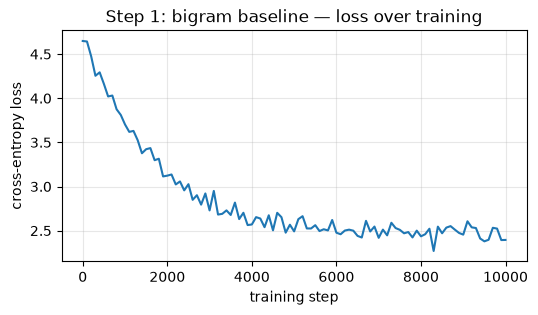

In [16]:
# The four-step training loop, factored out once and reused for every model below.
# The ONLY thing that changes step to step is the `model` argument.
history_by_step = {}   # collect each model's loss curve for a comparison plot at the end

@torch.no_grad()
def estimate_loss(model, batch_fn, n_batches=30):
    """A single training batch's loss is noisy. Average the loss over many held-out
    (validation) batches for a stable estimate of how good the model really is."""
    was_training = model.training
    model.eval()                                  # dropout off, deterministic
    losses = torch.zeros(n_batches)
    for i in range(n_batches):
        xb, yb = batch_fn('val')
        _, loss = model(xb, yb)
        losses[i] = loss.item()
    if was_training:
        model.train()
    return losses.mean().item()

def train(model, batch_fn, steps=10000, lr=1e-3, label=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)  # AdamW = gradient descent, auto step-size
    history = []
    for step in range(steps):
        xb, yb = batch_fn('train')             # sample a random batch of (input, target) pairs
        logits, loss = model(xb, yb)           # 1+2. predict and score (forward pass)
        optimizer.zero_grad(set_to_none=True)  #   5. clear last step's gradients
        loss.backward()                        # 3. assign blame (backprop fills every .grad)
        optimizer.step()                       # 4. nudge every weight to reduce the loss
        if step % 100 == 0 or step == steps - 1:
            history.append((step, loss.item()))
    val_loss = estimate_loss(model, batch_fn)  # stable, held-out estimate for the summary
    if label is not None:
        history_by_step[label] = {'history': history, 'val_loss': val_loss}
    print(f'noisy final-batch loss = {history[-1][1]:.3f}   |   averaged val loss = {val_loss:.3f}')
    return history

def plot_loss(history, title):
    steps, vals = zip(*history)
    plt.figure(figsize=(6, 3))
    plt.plot(steps, vals)
    plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
    plt.title(title); plt.grid(alpha=0.3); plt.show()

history = train(bigram_model, get_batch, label='1: bigram (baseline)')
plot_loss(history, 'Step 1: bigram baseline — loss over training')

### Generate after training

The model has learned which characters tend to follow which. You'll see common letter pairs and spaces in roughly the right places, but no real words — a bigram has no memory beyond one character. That gives us our **baseline: ~2.5 validation loss.** Every numbered step from here is measured against it.

In [10]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(bigram_model.generate(idx, max_new_tokens=300)[0].tolist()))


Ass, y, l be, om, ou
IAUle, she.
Yods wouabe wethor surcothin.
Thu, thinert hdoy ces hity s ad pu hey firof me,


Wharopave he licasd f ntottitont th y, seenome thet t n mingis ay matay pp! he.
Maw, g arthllitr conartesuseat houroue, helay obr pradd matommbse ndy, by t gorero sthemit Teily: le?qME? 


## Step 2: Uniform Attention

**What changes:** each position can see the positions before it — but weighs them all equally (a plain average). This installs the machinery of **attention**; Step 3 makes the weights smart.

### The problem we're fixing

In the bigram, each token is an island: when predicting from position 5, positions 0–4 might as well not exist. We want every position to build its new representation from *all the positions up to and including itself*. The simplest way to combine several vectors is to average them.

### An average is a weighted sum — and a weighted sum is all attention is

Take one sequence: `x` has shape `(T, C)`, one `C`-dim vector per position. We want output position `t` to be a blend of input positions `0..t`. Any blend is a weighted sum:

```
out[t] = Σ_s wei[t, s] · x[s]
```

where `wei[t, s]` says how much of position `s` to pour into position `t`. Collect all those coefficients into a `(T, T)` matrix `wei` (short for *weights*) and the whole operation is determined by it. For a plain average over the past, with `T = 4`, `wei` is:

```
         s=0    s=1    s=2    s=3
t=0   [ 1.00,  0,     0,     0    ]   position 0 can only see itself
t=1   [ 0.50,  0.50,  0,     0    ]   half of position 0, half of 1
t=2   [ 0.33,  0.33,  0.33,  0    ]   a third each
t=3   [ 0.25,  0.25,  0.25,  0.25 ]   a quarter each
```

Read row `t` left to right: it's how position `t` distributes its attention over the sequence. The zeros above the diagonal mean "no peeking at the future" — position `t` can't blend in tokens it hasn't seen yet. Each row sums to 1, so the output is a genuine *average*, on the same scale as the inputs.

**This matrix is the single most important object in the notebook.** Its shape `(T, T)` and its job (mix the positions) never change from here on — what changes is only how its numbers get filled in. Step 2 hard-codes the uniform rows above; Step 3 *computes* them from the data, so the model learns which positions matter; Step 4 runs several such matrices in parallel. Same recipe, better ingredients.

One thing `wei` is *not*: a learned parameter. It doesn't live in `self.parameters()` and backprop never touches it here — it's rebuilt from scratch on every forward pass. (In Step 3 the *projections that produce* `wei` become learned, but `wei` itself always stays a freshly computed intermediate.)

### Building the uniform `wei` in code: three moves

1. `tril` — a lower-triangular matrix of 1s marks the *allowed* (past-and-present) entries; the upper triangle is the future.
2. `masked_fill(tril == 0, -inf)` — set the future entries to `-inf`.
3. `softmax` on each row — `exp(-inf) = 0` kills the future, and the equal surviving values become an equal split.

> **Why softmax here, when nothing needs to be a "probability"?** It does two jobs at once: `exp(-inf) = 0` enforces the causal mask, and dividing by the row total makes each row sum to 1. Feed it all-equal scores and you get exactly the uniform matrix above. In Step 3 the pre-softmax scores stop being equal, and this *same* softmax turns them into an unequal, learned blend.

### Where the mixing actually happens: `wei @ x`

`wei` is only the recipe; the matrix multiply cooks it. For one sequence, `(T, T) @ (T, C) → (T, C)`: output row `t` = `Σ_s wei[t,s] · x[s]` — exactly the weighted sum above, computed for all `t` in one shot. In the code, `x` carries a batch dimension `(B, T, C)` while `wei` is `(T, T)`; PyTorch **broadcasts** the multiply, applying the same `(T, T)` recipe to each of the `B` sequences independently. (Broadcasting = "reuse the smaller operand across the missing dimension" — the same rule that lets you add a scalar to an array.)

### Two supporting changes

- **The embedding splits in two.** The bigram used `Embedding(65, 65)` — token → 65 logits directly. Now: `Embedding(65, 32)` — the same kind of learned lookup table the embeddings notebook trained (there it was `65 × 10`), mapping each token into a 32-dim working space (`C = n_embd = 32`). Attention mixes vectors *in that space*, and a final `Linear(32, 65)` (`lm_head`) projects the mixed vectors to 65 logits. The middle space gives the model room to represent tokens richly before committing to a prediction.
- **Position embeddings.** The embeddings MLP encoded order for *free*: because it **concatenated** its 8 vectors in sequence, "the 1st character" and "the 5th character" landed in different weight columns. Averaging throws that away — `avg(a, b, c) = avg(c, a, b)` — so we have to restore order explicitly. Each *slot* gets its own learned vector (`Embedding(block_size, 32)`), added onto the token embedding. Now "the 1st character" and "the 5th character" carry distinguishable signals even when they're the same letter.

### Expect this to get *worse*

This model will score ~2.8 — worse than the bigram's ~2.5, and well above the previous notebook's MLP at ~2.0. A uniform average blurs the one signal that mattered (the current character) into seven older ones; it's a *downgrade* even from plain concatenation, which at least kept the positions separate. That's fine — Step 2 exists only to install the `wei @ x` machinery. Step 3 makes `wei` learned, and the blur becomes focus.

In [17]:
n_embd = 32   # the working-space dimension C: each token becomes a 32-number vector

class AttentionLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Token → 32-dim vector (a smaller working space, not vocab_size directly)
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # Slot index → 32-dim vector, so the model can tell positions apart
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # Project the mixed 32-dim vectors back to 65 vocab logits
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)                 # (B, T, 32) — what each token is
        pos_emb = self.position_embedding_table(torch.arange(T))  # (T, 32)   — where each slot is
        x = tok_emb + pos_emb                                     # (B, T, 32) — pos_emb broadcasts over B

        # Build the uniform causal attention weights (fixed, not learned here)
        tril = torch.tril(torch.ones(T, T))               # 1s on/below diagonal (allowed), 0s above (future)
        wei = torch.zeros((T, T))                          # equal pre-softmax scores everywhere
        wei = wei.masked_fill(tril == 0, float('-inf'))    # future positions → -inf
        wei = F.softmax(wei, dim=-1)                       # each row: 0 on the future, equal split on the past
        x = wei @ x                                        # (T,T) @ (B,T,32) broadcasts over B → (B,T,32)

        logits = self.lm_head(x)                            # (B, T, 65) — project to vocab

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]  # crop to the last block_size tokens (position table is fixed-size)
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
attn_model = AttentionLanguageModel()
print(f'Parameters: {sum(p.numel() for p in attn_model.parameters()):,}')

Parameters: 4,481


Before training, let's make `wei` visible. Here is the exact matrix the model builds for a length-8 sequence — a heatmap where row `t` is the position doing the looking and column `s` is the earlier position being looked at. (Step 3 will give these two roles proper names, *query* and *key*; the plot labels use them so this heatmap stays comparable with the learned one there.) The lower-triangular "staircase" is the causal mask (no peeking at the future); the equal shading within each row is the uniform average.

wei (rounded):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


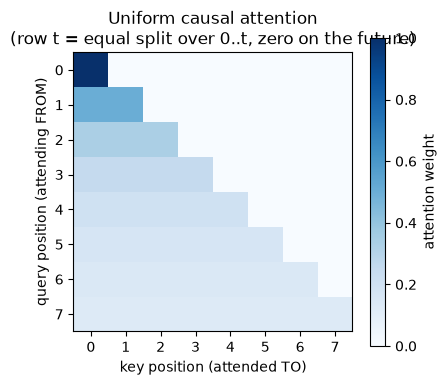

In [19]:
# Let's SEE the uniform attention matrix `wei` for a length-8 sequence.
# Row t = "how position t distributes its attention over positions 0..7".
T = 8
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T)).masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
print('wei (rounded):')
print(wei.round(decimals=4))

plt.figure(figsize=(4.5, 4))
plt.imshow(wei, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='attention weight')
plt.xlabel('key position (attended TO)'); plt.ylabel('query position (attending FROM)')
plt.title('Uniform causal attention\n(row t = equal split over 0..t, zero on the future)')
plt.xticks(range(T)); plt.yticks(range(T))
plt.show()
# Read it: the top-left cell is 1.0 (position 0 can only see itself); the bottom row spreads
# 0.125 across all 8 positions; the whole upper triangle is white (0 weight on future tokens).

### Training

The same `train()` function from the baseline — we just hand it the new model. This is the payoff of factoring the loop out: from here on, every step is one `train(...)` call, and only the model differs.

noisy final-batch loss = 2.796   |   averaged val loss = 2.826


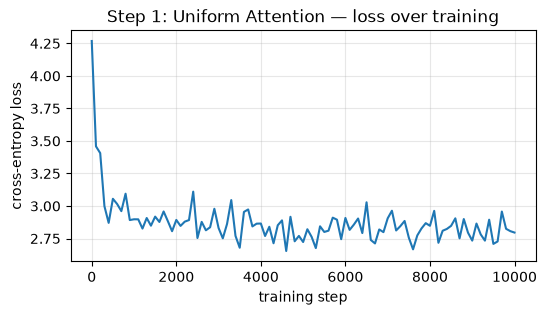

In [13]:
# Same train() as the baseline — only the model changed. The training logic is identical.
history = train(attn_model, get_batch, label='2: uniform attn')
plot_loss(history, 'Step 2: Uniform Attention — loss over training')

### Generate after training

Loss ~2.8 — *worse* than the bigram's ~2.5. Uniform averaging dilutes every token's contribution. By position 7, each token only contributes 1/8 of the signal. The model can't focus on what matters.

In [14]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(attn_model.generate(idx, max_new_tokens=300)[0].tolist()))


SwhoAu wsrsd ha,thay? .

L
EEBONEIHROG :

u
noMwls rlrea
ohd O'vr eyt aoeis  f eheudh - dohodft eottpr a nfofbaey r,yi:
 svhho tout csdhe,ak ce
 Bopo  immd iska:  betptsro ai nnn. qeodsyf. hkoe
e
tgn.Fhe S wowenenh t tcheaohresmbgne biilsdsa adb,dgn
m oot worAur?w
 aIosets w tieeae a ntnrgoo  u,h md


## Step 3: Self-Attention

**What changes:** in Step 2, `wei` was hard-coded to a uniform average. Now the model *computes* `wei` from the tokens themselves — so it can learn which earlier tokens to lean on. This is the idea that makes transformers work.

### The question Step 2 left open

Step 2 built the machinery — `wei @ x` mixes the positions — but filled `wei` with a fixed uniform average. That average is dumb: predicting after `"King:"`, it blends `K`, `i`, `n`, `g`, `:` equally, even though the `:` is the single most predictive character (it signals a speaker line about to start). We want the position just after the colon to *choose* to weight the colon heavily.

So the real question is the one Step 2 set up: **where should the numbers in `wei` come from?** Entry `wei[i, j]` means "how much should position `i` pull from position `j`" — so it has to be computed from what is actually sitting at positions `i` and `j`. That single requirement forces everything below.

### Query and Key: manufacturing `wei` from the data

To score how well position `i` and position `j` go together, give each position two learned vectors:
- a **query** — "what am I looking for?" (position `i`'s side of the match)
- a **key** — "what do I contain / advertise?" (position `j`'s side)

Each is just its own `Linear` layer — a learned projection of the token's embedding `x`, the same learned-lookup idea as everywhere else, now producing "search terms" and "tags." Then the score is the **dot product** `wei[i, j] = query[i] · key[j]`.

Why a dot product? It is large when two vectors point the same way, so it measures **alignment**: "does what `i` is looking for match what `j` advertises?" It's a soft, learned version of a dictionary lookup — the query is the search, the keys are the tags, and instead of one exact hit you get a weighted blend across all matches.

With tiny 3-dim vectors, the "alignment" claim is just arithmetic:

```
q[i] = [2, 0, 1]   k[j]  = [1, 0, 2]   →   q·k = 2·1 + 0·0 + 1·2 = 4    aligned: strong match
q[i] = [2, 0, 1]   k[j'] = [0, 3, 0]   →   q·k = 0·0 + 0·3 + 1·0 = 0    orthogonal: no match
```

Token `j` scores high because its key has weight in the same dimensions the query is probing; token `j'` advertises entirely different dimensions and scores zero.

Do this for every `(i, j)` pair and you have filled in the whole `(T, T)` matrix — the same `wei` as Step 2, but now *computed from the data* instead of hard-coded. The two steps that finish it are unchanged from Step 2: mask the future to `-inf`, then softmax each row. Step 2 fed softmax equal scores and got a flat average; now the scores are unequal, and the *same* softmax turns them into a learned, lopsided blend.

### Value: what actually gets mixed

One thing quietly changes from Step 2. There we mixed the raw embeddings: `wei @ x`. Self-attention mixes a *third* learned projection instead — the **value**, "what information do I hand over if attended to":

```
out = wei @ v        (not wei @ x)
```

**Why split value from key?** If key and value were the same vector, a token's "am I relevant?" signal and its "here is my information" payload would be forced to be identical. Splitting them lets a token be very findable (strong key–query match) while contributing something else entirely (its value). So each token emits three projections of `x`: a **query** and a **key** to *build* `wei`, and a **value** to be *mixed* by it.

Because all three are projections of the *same* sequence `x`, this is called **self**-attention: the sequence attends to itself. (Later variants let one sequence's queries attend to another sequence's keys and values — that's cross-attention. Here everything comes from `x`.)

### The flow, by shape

For one head, `head_size = 16`, one sequence of length `T`:

| Line | Operation | Shape | Meaning |
|------|-----------|-------|---------|
| `k = key(x)` | project | `(T, 16)` | each token's advertised content |
| `q = query(x)` | project | `(T, 16)` | each token's search query |
| `q @ k.transpose(-2,-1)` | all query·key dot products | `(T, T)` | raw alignment scores |
| `* head_size**-0.5` | scale | `(T, T)` | keep scores in a sane range (below) |
| `masked_fill(..., -inf)` + `softmax` | mask future + normalize | `(T, T)` | each row = a learned blend over the past |
| `v = value(x)` | project | `(T, 16)` | each token's payload |
| `wei @ v` | weighted sum of payloads | `(T, 16)` | the attended output |

> **Decoding `q @ k.transpose(-2, -1)`.** We need every query dotted with every key. `q` is `(T, 16)` and `k` is `(T, 16)`; to multiply them we transpose `k`'s last two axes to `(16, T)`, so `(T, 16) @ (16, T) → (T, T)`. Entry `[i, j]` is exactly `q[i] · k[j]`. (`transpose(-2, -1)` swaps the last two dimensions, leaving the batch dimension alone; with the real batched tensors it's `(B, T, 16) @ (B, 16, T) → (B, T, T)`.)

**Why `head_size = 16` when `n_embd = 32`?** The head projects the 32-dim working space down to a 16-dim space just for this comparison — `head_size` is a free hyperparameter, not pinned down by anything yet. With a single head we simply pick 16; Step 4 gives the real reason, when four heads split the 32-dim space among themselves.

**Why `/ sqrt(head_size)`?** The scores are sums of `head_size` products, so their size grows with the dimension — with 16 dims they can get large. Recall softmax exponentiates: feed it large-gap numbers and it becomes "peaky," dumping ~all the weight on one token and ~0 elsewhere. Near-0 weights have near-0 gradient, so training stalls. Dividing by `sqrt(16) = 4` rescales the scores so softmax stays soft and gradients keep flowing.

**What the model learns:** Q, K, V are just weight matrices, updated by backprop like everything else. Nobody tells it "attend to colons" — it discovers, because doing so lowers the loss, that queries after a colon should align with keys on capitalized words. We'll visualize an actual learned pattern right after training.

In [15]:
head_size = 16

class Head(nn.Module):
    """One self-attention head: learns Q, K, V projections and produces an attended output."""
    def __init__(self, head_size):
        super().__init__()
        self.head_size = head_size   # remember our own width; used for the 1/sqrt scaling below
        # Three separate learned projections, n_embd(32) → head_size(16). bias=False is conventional.
        self.key   = nn.Linear(n_embd, head_size, bias=False)  # "what do I contain?"
        self.query = nn.Linear(n_embd, head_size, bias=False)  # "what am I looking for?"
        self.value = nn.Linear(n_embd, head_size, bias=False)  # "what should I contribute?"
        # tril is a fixed mask, not a learned weight. register_buffer stores it with the module
        # (moves with .to(device), saved in state_dict) without treating it as a parameter.
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape                          # x is (B, T, 32)
        k = self.key(x)    # (B, T, 16) — every token advertises what it contains
        q = self.query(x)  # (B, T, 16) — every token broadcasts what it wants

        # All query·key dot products at once. transpose makes k (B, 16, T) so the matmul contracts
        # over the 16-dim head axis: (B, T, 16) @ (B, 16, T) → (B, T, T). Entry [b,i,j] = q[i]·k[j].
        wei = q @ k.transpose(-2, -1) * self.head_size**-0.5      # scale by 1/sqrt(16) to keep softmax soft
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # future positions → -inf (causal mask)
        wei = F.softmax(wei, dim=-1)               # (B, T, T) — each row is a learned blend over the past

        v = self.value(x)  # (B, T, 16) — the payload each token hands over
        out = wei @ v      # (B, T, T) @ (B, T, 16) → (B, T, 16) — weighted sum of payloads
        return out


class SelfAttentionLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(head_size)
        # lm_head maps from head_size (16) here, because the head outputs 16-dim vectors
        self.lm_head = nn.Linear(head_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T))
        x = tok_emb + pos_emb        # (B, T, 32)
        x = self.sa_head(x)           # (B, T, 16) — attention gathers context, reduces dim to head_size
        logits = self.lm_head(x)      # (B, T, 65) — project to vocab

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
sa_model = SelfAttentionLanguageModel()
print(f'Parameters: {sum(p.numel() for p in sa_model.parameters()):,}')

Parameters: 4,977


### Training

Same loop. The Q, K, V weight matrices are now learned parameters — backprop updates them just like any other weight. The model discovers which attention patterns reduce the loss.

noisy final-batch loss = 2.408   |   averaged val loss = 2.402


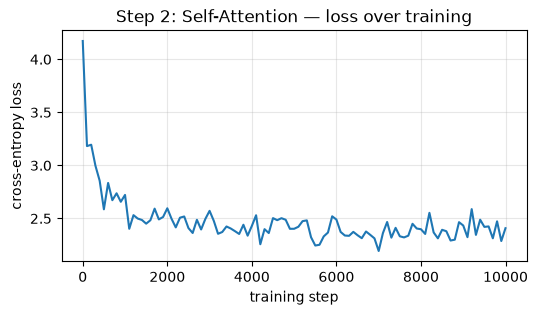

In [16]:
# Same train() — but now Q, K, V are learned parameters, so backprop discovers useful
# attention patterns while driving the loss down.
history = train(sa_model, get_batch, label='3: self-attn')
plot_loss(history, 'Step 3: Self-Attention — loss over training')

### Generate after training

Loss ~2.4 — a clear improvement over both the bigram (~2.5) and uniform averaging (~2.8). The model can now focus on specific tokens. But one head = one attention pattern. It can't track multiple types of relationships at once.

In [17]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(sa_model.generate(idx, max_new_tokens=300)[0].tolist()))


Mud sheirt el th her surim:
O wt min not, as.
Cando antewaigks,
A'ses.

Fre thalt calitier to tos hes?

Oncom Pavent be-t-
Whr, oacre, whofourre ald yonondeas net till.
INE:
His!

YO:
Atw et tos hitice akind st the;
Sist liy searn verpra mps p ces bour ecof Lot hon. O's wicke waman;
Win!
Antthis, Ca


### Look at what it learned

The text output is suggestive, but the real story is in `wei`. Let's feed the trained head a concrete string and plot its attention matrix — the same kind of heatmap as the uniform one in Step 2, but now the weights are *learned*. Where Step 2's rows were flat, expect these to be lumpy: each position has decided some earlier characters matter more than others.

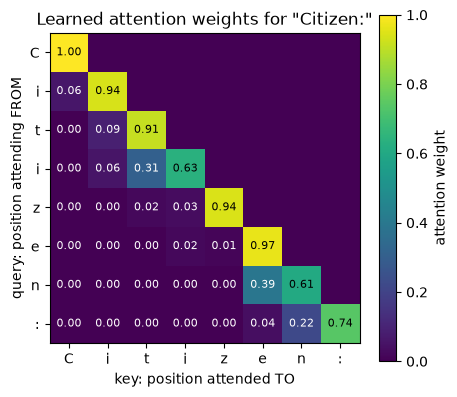

In [18]:
# Visualize the LEARNED attention pattern. We push a real 8-character string through the
# trained head and read out `wei` — the (T, T) matrix of how much each position attended
# to each earlier one. Compare this to the flat uniform matrix from Step 2.
sample = "Citizen:"                                   # 8 chars, ends in the tell-tale colon
ctx = torch.tensor([encode(sample)])                  # (1, 8)

h = sa_model.sa_head
with torch.no_grad():                                 # just inspecting, no training
    x = sa_model.token_embedding_table(ctx) + sa_model.position_embedding_table(torch.arange(8))
    k, q = h.key(x), h.query(x)
    wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5
    wei = wei.masked_fill(h.tril[:8, :8] == 0, float('-inf'))
    wei = F.softmax(wei, dim=-1)[0]                    # (8, 8) for this one sequence

plt.figure(figsize=(5, 4.5))
plt.imshow(wei, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='attention weight')
plt.xticks(range(8), list(sample)); plt.yticks(range(8), list(sample))
plt.xlabel('key: position attended TO'); plt.ylabel('query: position attending FROM')
plt.title('Learned attention weights for "Citizen:"')
for i in range(8):                                    # annotate each cell with its weight
    for j in range(i + 1):
        plt.text(j, i, f'{wei[i, j]:.2f}', ha='center', va='center',
                 color='white' if wei[i, j] < 0.5 else 'black', fontsize=8)
plt.show()
# Unlike Step 2's flat rows, the weights are now UNEVEN: each row concentrates on the earlier
# characters this head found most useful for predicting what follows. The pattern was never
# programmed — backprop discovered it purely by minimizing next-character loss.

## Step 4: Multi-Head Attention

**What changes:** Instead of one attention head, we run 4 in parallel and concatenate their outputs.

**How it works:** A single head has one set of Q, K, V weights, which produces one `(T, T)` attention pattern. That pattern might learn to look at the immediately preceding character, but then it *can't also* look at punctuation 5 positions back — it's one pattern per head.

Multi-head attention solves this by running several heads side by side. With `n_embd = 32` and 4 heads, each head works with `32 / 4 = 8` dimensions. Each head has its own Q, K, V weight matrices, so each one independently learns a different attention pattern.

**How do heads decide what to focus on?** They don't — nothing explicitly assigns roles to heads. Each head's Q, K, V weights are initialized randomly and updated by gradient descent independently. During training, if two heads happen to learn the same pattern, there's no loss improvement from the duplicate, so gradients push one of them toward a different pattern that actually helps. Over time, heads naturally specialize: one might learn to attend to the previous vowel, another to the nearest space, another to punctuation. This emergent specialization is a result of the optimization, not explicit programming.

After all heads run, their outputs (each 8-dimensional) are concatenated back to 32 dimensions, and a `proj` linear layer mixes them. This projection is important: without it, the heads can't combine their findings — head 1's output can't interact with head 2's. The projection lets the model learn things like "if head 1 found a colon AND head 3 found a capital letter, then..."

**Implementation:** `MultiHeadAttention` wraps an `nn.ModuleList` of `Head` instances. In `forward`, each head runs on the same input (they all see the same embeddings), the outputs are concatenated along the last dimension, and the `proj` layer mixes them. Since the concatenated output is `n_embd`-dimensional, `lm_head` maps from `n_embd` to `vocab_size` (unlike Step 3 where it mapped from `head_size`).

In [19]:
n_heads = 4
head_size = n_embd // n_heads  # 32 // 4 = 8 dimensions per head (heads split the 32 dims between them)

class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, head_size):
        super().__init__()
        # Each head has its own Q, K, V weights — they learn independent attention patterns
        self.heads = nn.ModuleList([Head(head_size) for _ in range(n_heads)])
        # After concatenation, mix the heads' outputs so they can interact
        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self, x):
        # Run all heads on the same input; each returns (B, T, 8). Concatenate along the last
        # axis → (B, T, 32): the 4 heads' outputs sit side by side, reassembling the full width.
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)  # (B, T, 32) — linear mix so heads can combine their findings
        return out


class MultiHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_heads = MultiHeadAttention(n_heads, head_size)
        # Back to mapping from n_embd (32) since heads concatenate back to full width
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T))
        x = tok_emb + pos_emb     # (B, T, 32)
        x = self.sa_heads(x)       # (B, T, 32) — multi-head attention
        logits = self.lm_head(x)   # (B, T, 65)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
mh_model = MultiHeadModel()
print(f'Parameters: {sum(p.numel() for p in mh_model.parameters()):,}')

Parameters: 8,609


### Training

Same loop. Now 4 heads are trained in parallel — each head's Q, K, V weights are updated independently, and the projection layer learns to combine their outputs.

noisy final-batch loss = 2.178   |   averaged val loss = 2.248


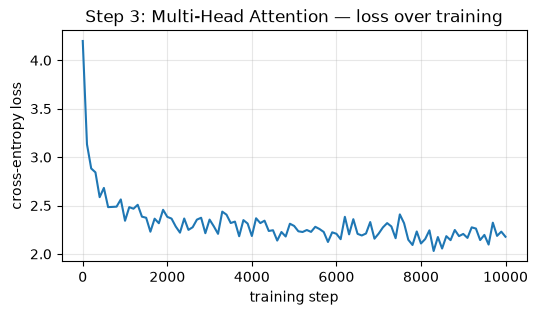

In [20]:
# Same train() — now 4 heads + a projection layer learn together (8.6k params vs 5k).
history = train(mh_model, get_batch, label='4: multi-head')
plot_loss(history, 'Step 4: Multi-Head Attention — loss over training')

### Generate after training

Loss ~2.2. Four heads tracking different patterns beats one head. The output starts showing longer word fragments.

In [21]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(mh_model.generate(idx, max_new_tokens=300)[0].tolist()))


thou ther the cou the sonert eako us at ucetich cre whif mamto cuce, 'll teave and any icEn; sond feset I the lung in pre thy is torien's flour, thon, furvetie
deseeed me mile?

MERCENEBCERMIO:
At!
DUSSAz:
Gongdtret's ands hom cofr ouls nut you
Lour dow Cham om, set,
Inderewer my anve the Glowne evi


## Step 5: Feed-Forward Layer

**What changes:** After attention, each token passes through a small neural network (two linear layers with a ReLU in between).

**How it works:** Attention computes a weighted sum of value vectors — a *linear* operation. It can gather information ("there's a colon 2 positions back and a capital letter 5 positions back"), but a weighted sum can't do nonlinear reasoning on what it gathered. The feed-forward network (FFN) adds that ability. It's an ordinary MLP, exactly like the one built neuron-by-neuron in the neural-net notebook — a `Linear`, a `ReLU`, a `Linear` — applied to each position.

> **ReLU, same as before.** `ReLU(z) = max(0, z)` — pass positives through, clamp negatives to zero. It's the identical nonlinearity from the neural-net notebook, and it's here for the identical reason: without a nonlinearity between them, two stacked `Linear` layers collapse into one, and the model could only ever represent straight-line functions. ReLU is what lets the FFN combine features in nonlinear ways.

Think of it as two stages: attention answers "what should I look at?"; the FFN answers "what do I do with what I found?" A rule like "a colon after a capitalized word means a new speaker" needs several features combined nonlinearly — attention gathers them, the FFN reasons over them.

The FFN processes each token position independently (no cross-token mixing — that's attention's job). It expands the dimension 4×, applies ReLU, then projects back down:

```
(B, T, 32) → Linear → (B, T, 128) → ReLU → (B, T, 128) → Linear → (B, T, 32)
```

The 4× expansion gives a wider scratchpad to compute intermediate features in. This ratio comes from the original transformer paper and stuck as the default.

**Implementation:** `FeedForward` is an `nn.Sequential` of those three layers. In `forward`, it runs right after attention: `x = self.sa_heads(x)` then `x = self.ffwd(x)`. Shapes are unchanged — `(B, T, 32)` in, `(B, T, 32)` out.

In [22]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # expand: 32 → 128 (wider scratchpad)
            nn.ReLU(),                        # nonlinearity — zeroes out negatives (same as neural-net nb)
            nn.Linear(4 * n_embd, n_embd),   # project back: 128 → 32
        )

    def forward(self, x):
        return self.net(x)  # applied independently to each of the B*T token positions


class FFModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_heads = MultiHeadAttention(n_heads, head_size)
        self.ffwd = FeedForward(n_embd)  # NEW: per-token reasoning after attention
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T))
        x = tok_emb + pos_emb     # (B, T, 32)
        x = self.sa_heads(x)       # (B, T, 32) — gather context from other tokens
        x = self.ffwd(x)           # (B, T, 32) — think about what was gathered
        logits = self.lm_head(x)   # (B, T, 65)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
ff_model = FFModel()
print(f'Parameters: {sum(p.numel() for p in ff_model.parameters()):,}')

Parameters: 16,961


### Training

Same loop. The FFN's weights are trained alongside the attention weights — backprop flows through FFN → attention → embeddings in one pass.

noisy final-batch loss = 2.087   |   averaged val loss = 2.164


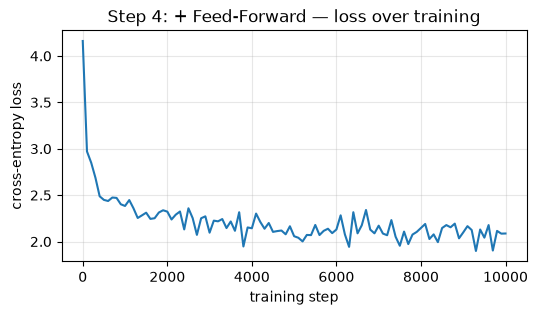

In [23]:
# Same train() — backprop now flows through FFN → attention → embeddings in one pass.
history = train(ff_model, get_batch, label='5: + feed-forward')
plot_loss(history, 'Step 5: + Feed-Forward — loss over training')

### Generate after training

Loss ~2.1. The FFN lets the model reason about gathered context — not just collect it. More recognizable words start appearing.

In [24]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(ff_model.generate(idx, max_new_tokens=300)[0].tolist()))



MELLABUKE VIVIO:
Dowith suight gut chare, kice
Boffo ming be I a neet thy nairn, ampe comfed knether nente pewow: antrt thing heatmegne be lid andd aptaime: the ris be dainsets watine, jaing of of the mun ram go my ketfoord mares'd of your eall, wenncess wil of stach to be or upe aweeld.

MepecemWa


## Step 6: Residual Connections + Layer Norm

**What changes:** We wrap attention and feed-forward in *residual connections* and add *layer normalization*, packaging the pair into a reusable `Block`. Neither changes what the model computes much on its own — they're the plumbing that makes **stacking blocks deep** (Step 7) actually trainable. Two problems appear as depth grows; here's each, with its fix.

**Problem 1: Vanishing gradients.** Backprop sends the error signal from the loss backward through every layer, and by the chain rule each layer *multiplies* the gradient by its own local derivative (exactly the chain-rule product from the neural-net notebook: `dLoss/dw = dLoss/df · df/dg · … · dg/dw`). Stack many layers and you multiply many such factors together; if they're mostly below 1, the product shrinks toward zero. The early layers then receive almost no signal and stop learning. It's a game of telephone: the message degrades with every hop.

**Fix: Residual connections.** Instead of `x = f(x)`, compute `x = x + f(x)`. That `+ x` is a bypass: during backprop the addition sends the gradient *straight through* unchanged, in addition to the path through `f`. So even if `f`'s local derivatives are tiny, the shortcut keeps a full-strength gradient flowing to the early layers. Think of it as an express lane past each layer. It also reframes each layer's job: not "recompute the signal" but "compute a small *correction* to add" — usually easier to learn.

**Problem 2: Unstable activations.** As vectors pass through many linear layers and ReLUs, their numbers can drift to wildly different scales — one layer's outputs in the hundreds, another's in the thousandths. A single learning rate can't suit all of them, and training gets brittle.

**Fix: Layer norm — but first, mean and variance.** LayerNorm "normalizes each token's vector to zero mean and unit variance." Those two words are the only statistics you need here, and both are plain averages over the numbers *in one token's vector*:

- **Mean** = the ordinary average: `mean = (x₁ + x₂ + … + x_C) / C`. It's the center of the values.
- **Variance** = the average squared distance from the mean: `var = mean((xᵢ − mean)²)`. It measures spread — small variance means the numbers are bunched near the mean, large variance means they're scattered. (Its square root is the standard deviation, the "typical distance from center.")

**Normalizing** means: subtract the mean (so the values now center on 0) and divide by `sqrt(var)` (so the typical spread becomes 1). The vector keeps its *shape* — which entries are relatively big or small — but is re-expressed on a standard scale, wiping out the drift. LayerNorm then applies a learned per-feature **scale** and **shift** (`γ` and `β`), so the model can undo or re-tune the normalization if that helps. We normalize *before* each sub-layer ("pre-norm," the modern default):

```python
x = x + attention(norm(x))    # normalize → attend → add the residual back
x = x + feedforward(norm(x))  # normalize → FFN    → add the residual back
```

> **LayerNorm vs BatchNorm.** "Layer" norm normalizes across the *features of one token* (the `C` numbers of a single position), independently of every other token in the batch. That's why it's stable regardless of batch size — a nice property for language models, where batches and sequence lengths vary.

**The `Block` class** bundles attention + FFN + their two residuals + two norms into one unit. We also add a final `ln_f` after the block, right before projecting to logits. With a single block the payoff is modest; in Step 7 we stack four, and these two fixes are what keep that stack trainable. The next cell shows LayerNorm on real numbers so the "zero mean, unit variance" claim is concrete.

In [25]:
# LayerNorm on real numbers, so "zero mean, unit variance" is concrete.
# Take one token's 6-dim vector with a deliberately drifted scale and offset.
v = torch.tensor([10.0, 12.0, 8.0, 14.0, 9.0, 11.0])

mean = v.mean()
var = ((v - mean) ** 2).mean()          # average squared distance from the mean
v_norm = (v - mean) / torch.sqrt(var + 1e-5)   # subtract mean, divide by spread (eps avoids /0)

print(f'original : {v.tolist()}')
print(f'mean = {mean:.2f},  variance = {var:.2f},  std = {torch.sqrt(var):.2f}\n')
print(f'normalized       : {[round(x, 3) for x in v_norm.tolist()]}')
print(f'  its mean ≈ {v_norm.mean():.3f}  (≈ 0),   its variance ≈ {v_norm.var(unbiased=False):.3f}  (≈ 1)')

# nn.LayerNorm does exactly this (then applies a learned scale γ and shift β, both starting at 1 and 0):
ln = nn.LayerNorm(6)
print(f'\nnn.LayerNorm(v): {[round(x, 3) for x in ln(v).tolist()]}   (matches, since γ=1, β=0 at init)')

original : [10.0, 12.0, 8.0, 14.0, 9.0, 11.0]
mean = 10.67,  variance = 3.89,  std = 1.97

normalized       : [-0.338, 0.676, -1.352, 1.69, -0.845, 0.169]
  its mean ≈ -0.000  (≈ 0),   its variance ≈ 1.000  (≈ 1)

nn.LayerNorm(v): [-0.338, 0.676, -1.352, 1.69, -0.845, 0.169]   (matches, since γ=1, β=0 at init)


In [26]:
class Block(nn.Module):
    """One transformer block: attention + feed-forward, each wrapped in a norm and a residual."""
    def __init__(self, n_embd, n_heads):
        super().__init__()
        head_size = n_embd // n_heads
        self.sa = MultiHeadAttention(n_heads, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)  # normalize before attention
        self.ln2 = nn.LayerNorm(n_embd)  # normalize before feed-forward

    def forward(self, x):
        # Pre-norm + residual: normalize, run the sub-layer, then ADD the original x back.
        # The `x +` is the express lane that keeps gradients strong through deep stacks.
        x = x + self.sa(self.ln1(x))     # norm → attend → add residual
        x = x + self.ffwd(self.ln2(x))   # norm → FFN    → add residual
        return x


class BlockModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.block = Block(n_embd, n_heads)    # one transformer block
        self.ln_f = nn.LayerNorm(n_embd)        # final norm before the output projection
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T))
        x = tok_emb + pos_emb     # (B, T, 32)
        x = self.block(x)          # (B, T, 32) — attention + FFN with residuals and norms
        x = self.ln_f(x)           # (B, T, 32) — final normalization
        logits = self.lm_head(x)   # (B, T, 65)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
block_model = BlockModel()
print(f'Parameters: {sum(p.numel() for p in block_model.parameters()):,}')

Parameters: 17,153


### Training

Same loop. The residual connections mean gradients now have a direct path back to the embeddings — even through the attention and FFN layers. The LayerNorm parameters (a scale and shift per feature) are also learned.

noisy final-batch loss = 2.020   |   averaged val loss = 2.106


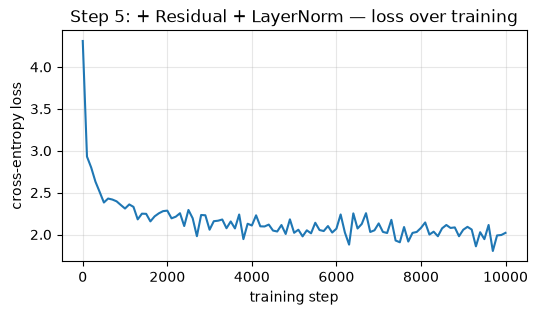

In [27]:
# Same train() — residuals give gradients a direct path back to the embeddings.
history = train(block_model, get_batch, label='6: + residual/norm')
plot_loss(history, 'Step 6: + Residual + LayerNorm — loss over training')

### Generate after training

Loss ~2.1 — only a small step down from Step 5, and that is expected. With a *single* block, residuals and LayerNorm barely move the loss on their own; their real payoff is making a *deep* stack trainable, which is what Step 7 cashes in. The generated text keeps improving, with real words and speaker-like patterns emerging.

In [28]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(block_model.generate(idx, max_new_tokens=300)[0].tolist()))



MERCK:
What bany mosing sve his frich henck cenctort a mudsink a beet to will nan.

DUPERENCENTESTERS:
Far Sewow:
Thirt to Gard asmagn obling say, badge.
How awarry bouder,
Atish tise, jain?
Whony the mun you go my ke for of Erst'd of rave eyou, wennch, you somest holl,
Ne? Nowake weeldose apece my


## Step 7: Full GPT — Stacking Layers + Dropout + Scale Up

**What changes:** We stack 4 blocks deep, add dropout, and increase the model's dimensions. This is the complete GPT architecture — everything from Steps 2–6, repeated and scaled.

**How stacking works:** A single block does one round of "gather context (attention) → process it (feed-forward)." Stack 4 and each block builds on the previous one's output, learning progressively more abstract patterns:
- Block 1 processes raw character embeddings — simple stuff, like common letter pairs.
- Block 2 reads block 1's output — that already encodes letter-pair info, so block 2 can spot word fragments.
- Blocks 3–4 build further — word-level patterns, speaker names, punctuation structure.

This only works because of the residual connections from Step 6: each block *adds a refinement* to the running signal rather than overwriting it, so information from early blocks survives to the top, and gradients reach the bottom.

**How dropout works:** During training, dropout randomly zeroes out 20% of the values in a tensor (a fresh random 20% each step). This sounds destructive, but it stops the model leaning on any single feature — if any neuron might vanish next step, the model must spread its knowledge redundantly. That redundancy is what fights **overfitting** (memorizing the training text instead of learning general patterns). Dropout must be *on* during training and *off* during generation, and PyTorch ties that to a mode flag: `model.train()` enables it, `model.eval()` disables it. We call `model.train()` before the loop and `model.eval()` before generating — you'll see both in the code.

We add dropout in three places: on the attention weights, after the FFN, and after the multi-head projection.

**Scaling up:** More capacity to exploit the deeper architecture:
- `n_embd`: 32 → 64 — each token's vector is twice as wide.
- `block_size`: 8 → 32 — the model sees 32 characters of context instead of 8.
- `batch_size`: 32 → 64 — steadier gradients from averaging over more examples.

**Implementation:** Because the dimensions change, we redefine the components (`GPTHead`, `GPTMultiHeadAttention`, …) with the new sizes and dropout, and stack blocks with `nn.Sequential(*[GPTBlock(...) for _ in range(4)])`.

```
Tokens → Embedding + Position → Block × 4 → LayerNorm → Linear → Logits
```

In [29]:
# Scaled-up hyperparameters
gpt_block_size = 32   # 4x more context than before
gpt_n_embd = 64       # 2x richer embeddings
gpt_n_heads = 4
gpt_n_layers = 4      # 4 blocks deep
gpt_head_size = gpt_n_embd // gpt_n_heads  # 16
dropout = 0.2          # randomly disable 20% of activations during training

class GPTHead(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.head_size = head_size
        self.key   = nn.Linear(gpt_n_embd, head_size, bias=False)
        self.query = nn.Linear(gpt_n_embd, head_size, bias=False)
        self.value = nn.Linear(gpt_n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(gpt_block_size, gpt_block_size)))
        self.dropout = nn.Dropout(dropout)  # NEW: dropout on attention weights

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * self.head_size**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)    # randomly zero some attention weights during training
        v = self.value(x)
        return wei @ v


class GPTMultiHeadAttention(nn.Module):
    def __init__(self, n_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([GPTHead(head_size) for _ in range(n_heads)])
        self.proj = nn.Linear(gpt_n_embd, gpt_n_embd)
        self.dropout = nn.Dropout(dropout)  # NEW: dropout after projection

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class GPTFeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),  # NEW: dropout after FFN
        )

    def forward(self, x):
        return self.net(x)


class GPTBlock(nn.Module):
    def __init__(self, n_embd, n_heads):
        super().__init__()
        head_size = n_embd // n_heads
        self.sa = GPTMultiHeadAttention(n_heads, head_size)
        self.ffwd = GPTFeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, gpt_n_embd)
        self.position_embedding_table = nn.Embedding(gpt_block_size, gpt_n_embd)
        # Stack 4 blocks — this is where depth comes from. Each block refines the previous
        # block's output; residuals (Step 6) let information from early blocks survive to the top.
        self.blocks = nn.Sequential(*[GPTBlock(gpt_n_embd, gpt_n_heads) for _ in range(gpt_n_layers)])
        self.ln_f = nn.LayerNorm(gpt_n_embd)
        self.lm_head = nn.Linear(gpt_n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T))
        x = tok_emb + pos_emb   # (B, T, 64)
        x = self.blocks(x)       # (B, T, 64) — pass through all 4 blocks in sequence
        x = self.ln_f(x)         # (B, T, 64) — final normalization
        logits = self.lm_head(x) # (B, T, 65)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -gpt_block_size:]   # crop to the last 32 tokens (position table size)
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
gpt_model = GPTLanguageModel()
print(f'Parameters: {sum(p.numel() for p in gpt_model.parameters()):,}')

Parameters: 209,729


### Training

First change to the training code: we need a new `get_batch` that uses the larger `block_size = 32` and `batch_size = 64`. The model is also ~12× bigger (210k params), so each step takes longer — but the loop itself is the same. Dropout is active during training and automatically disabled during generation.

noisy final-batch loss = 1.755   |   averaged val loss = 1.740


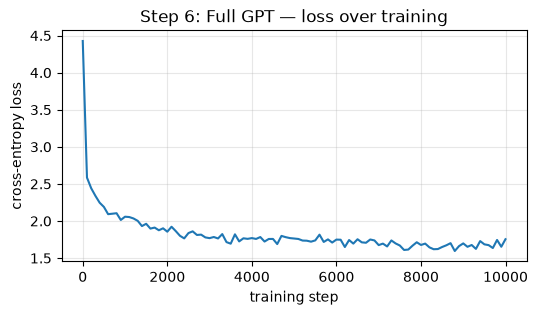

In [30]:
# The larger block_size (32) and batch_size (64) need their own get_batch.
gpt_batch_size = 64  # 2× more sequences per batch → steadier gradients

def get_batch_gpt(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - gpt_block_size, (gpt_batch_size,))
    x = torch.stack([d[i:i+gpt_block_size] for i in ix])    # 32 chars of context (was 8)
    y = torch.stack([d[i+1:i+gpt_block_size+1] for i in ix])
    return x, y

# Same train() as everywhere else — just a bigger model and a bigger batch function.
# This is the slow one (~210k params, 4 blocks); expect it to take a few minutes on CPU.
gpt_model.train()   # make sure dropout is ON for training
history = train(gpt_model, get_batch_gpt, label='7: full GPT')
plot_loss(history, 'Step 7: Full GPT — loss over training')

### Generate after training

Loss ~1.7 — the best by far. With 4 stacked blocks, more context (32 chars), and 50× more parameters, the model produces recognizable English words, speaker names with colons, and Shakespeare-like sentence structure.

In [31]:
gpt_model.eval()   # switch OFF dropout for generation (use the full model, deterministically wired)
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(gpt_model.generate(idx, max_new_tokens=500)[0].tolist()))



DUKE OF YORK:
We halm should his wornsing mine as carpt.

MARCIO:
And recienter in tto their cadly fly him mokes
And nowle, wretch! for out sincel to hoim to tears,
For the grue could stor: and my harge:
Letwixt would temphy scective Papent and won here and upon't.

NORTHUMBERLAND:
We, in his groash'd point.

SICINIUS:
The shamile sorrow heaves deter. But side, to enseeberly
What sir. Our swear I did shered baj'st?

First-hearl:
The kill lips if to one we the peit,
Tifferiest the
engel
The dren


### The whole progression in one plot

We stored each model's loss curve in `history_by_step`. Overlaying them tells the story of the notebook at a glance: the baseline sits around 2.5, Step 2 (uniform averaging) is the one curve that lands *higher* — the deliberate backfire — and every learned idea after it pulls the loss lower, with the full GPT well below the rest.

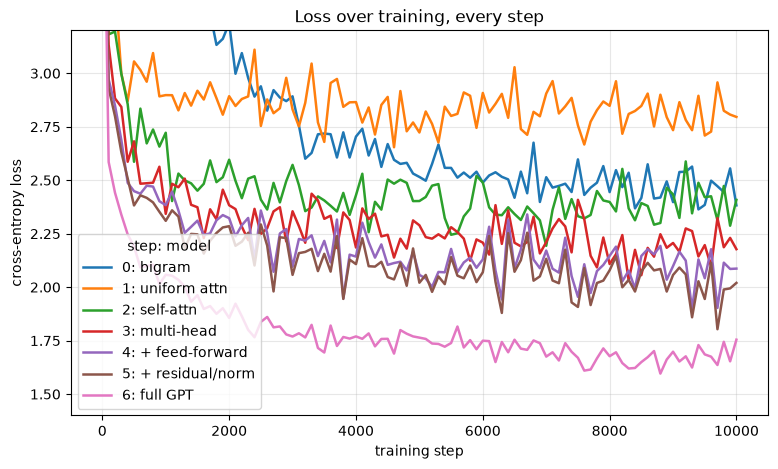

averaged validation loss by step:
  0: bigram              2.494
  1: uniform attn        2.826
  2: self-attn           2.402
  3: multi-head          2.248
  4: + feed-forward      2.164
  5: + residual/norm     2.106
  6: full GPT            1.740


In [32]:
# Every model's loss curve on one axis - the whole notebook's progression in a single picture.
plt.figure(figsize=(9, 5))
for label, rec in history_by_step.items():
    steps, vals = zip(*rec['history'])
    plt.plot(steps, vals, label=label, linewidth=1.8)
plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
plt.title('Loss over training, every step')
plt.legend(title='step: model'); plt.grid(alpha=0.3)
plt.ylim(1.4, 3.2)
plt.show()

# Stable held-out (validation) loss for each model, in build order:
print('averaged validation loss by step:')
for label, rec in history_by_step.items():
    print(f'  {label:22s} {rec["val_loss"]:.3f}')

## Summary

| Step | What we added | Parameters | Loss |
|------|--------------|------------|------|
| 1 | Bigram (baseline) + `nn.Module` — no context | 4,225 | ~2.49 |
| 2 | Uniform averaging | 4,481 | ~2.83 |
| 3 | Learned attention (Q, K, V) | 4,977 | ~2.40 |
| 4 | Multiple attention heads | 8,609 | ~2.25 |
| 5 | Feed-forward layer | 16,961 | ~2.16 |
| 6 | Residual connections + layer norm | 17,153 | ~2.11 |
| 7 | **4 layers + dropout + scale up** | **209,729** | **~1.74** |

*(Loss here is the averaged held-out validation loss that `train()` prints; lower is better. Steps 5→6 barely move because a single block gains little from residuals/norm — their payoff is unlocking the 4-layer depth in Step 7.)*

Step 2 is intentionally *worse* than the bigram baseline — uniform averaging blurs everything. The real breakthrough is Step 3, when the model learns which tokens matter.

**Put this table next to the previous notebook.** The embeddings **MLP** — 8 characters of context, no attention — sat at **~2.0**. Read down the Loss column with that in mind: *every single-block model here, Steps 1 through 6, scores worse than that MLP.* Attention doesn't overtake it until Step 7 stacks blocks four deep and scales the model up, landing at ~1.74. The lesson of the whole series arc is therefore not "attention beats MLPs" — a lone head is a weaker per-position computation than a wide hidden layer. It's that **attention scales** where concatenate-and-MLP couldn't: it removes the previous notebook's three walls (private per-slot weights, parameters that grow with context, position-not-content weighting), and depth is where that pays off.

This is the same architecture (at much larger scale) behind GPT-2, GPT-3, and similar models.

### What we learned

- **Attention is a data-dependent weighted average** — `wei @ x`, nothing more. The whole invention is in how the `(T, T)` matrix `wei` gets its numbers: hard-coded uniform (Step 2) versus computed from queries and keys (Step 3).
- **`wei` is never a learned parameter** — it's rebuilt from the data on every forward pass. What's learned are the Q, K, V projections that *produce* it.
- **The attention weight between two tokens is a dot product** `q·k` — a soft, learned dictionary lookup. Scaling by `1/√head_size` keeps softmax from going peaky and killing gradients.
- **The causal mask is just `-inf` above the diagonal** before softmax — that single move is what forbids peeking at the future.
- **Heads specialize because duplication is useless**: nothing assigns them roles; a redundant head earns no loss reduction, so gradients push it toward a different pattern.
- **Attention gathers, feed-forward reasons** — the FFN is the same MLP as always, applied per position, giving the model nonlinear compute over what attention collected.
- **Residuals and LayerNorm are plumbing, not smarts**: `x + f(x)` keeps gradients flowing and normalization keeps scales sane. They barely move the loss on one block — their payoff is making *depth* trainable.
- **Depth is where the loss fell**: single-block refinements moved ~2.4 → ~2.1 (all still above the previous notebook's MLP at ~2.0); stacking 4 blocks and scaling up finally broke past it to ~1.74.
- **Judge models on held-out data** — the noisy final-batch training loss flatters; the averaged validation loss is the honest number.


## Next steps

Three directions to take this further:

1. **Train longer on GPU** — our GPT model barely scratches the surface at 10k steps on CPU. Move to GPU with `model.to('cuda')`, train for 100k+ steps, and you'll see noticeably more coherent Shakespeare with real words and sentence structure.

2. **Subword tokenizer (BPE)** — character-level tokenization means the model has to learn to spell every word from individual letters. A subword tokenizer like [tiktoken](https://github.com/openai/tiktoken) groups common character sequences into single tokens (e.g., `"the"` → one token instead of three), letting the model learn much faster with a ~50k vocabulary.

3. **Train on a real task** — instead of open-ended text generation, train on something with a measurable outcome: simple arithmetic (`"2+3=" → "5"`), translation between toy languages, or text completion with a structured prompt format. This makes it easier to evaluate whether the model actually learned the pattern vs. just memorizing statistics.


## Your turn: make it stick

Reading along is the comfortable half of learning. Before moving on, do these two things.

### 1. Summarize it yourself, then verify with an LLM

Close the notebook and write a summary from memory — a few sentences per question, no peeking:

- What is the matrix `wei`, what shape is it, and why is it *not* a learned parameter?
- What do query, key, and value each represent, and why must they be three *separate* projections?
- How does the causal mask work, mechanically? Why does softmax make `exp(-inf)` useful?
- Why divide the attention scores by `√head_size`?
- What do residual connections and LayerNorm each fix, and why did they barely move the loss until Step 7?

Then paste your summary into an LLM with a prompt like:

> *"I just built a GPT-style transformer from scratch, step by step from a bigram model. Here is my summary from memory: [your summary]. Check every claim for correctness, tell me what I've missed or muddled, then quiz me with three follow-up questions aimed at my weakest spot."*

### 2. Rebuild a small version

The highest-value piece to rebuild is the heart: **one attention head, from memory.**

1. Write a function taking a random `x` of shape `(B, T, C)` (say `2, 8, 32`) and producing the attended output, with fresh `nn.Linear` projections for Q, K, V, the `1/√head_size` scaling, causal mask, and softmax.
2. **Verify it** with three asserts before trusting it: every row of `wei` sums to 1; everything above the diagonal is exactly 0; changing the *last* token of `x` changes only the *last* row of the output (nothing leaks backward — this catches masking bugs the other checks miss).
3. Bolt your head onto the baseline bigram model (embedding → your head → `lm_head`) and train it on a slice of the data.

**Done when**: all three asserts pass and your model beats the bigram's ~2.5 validation loss. Bonus: plot your `wei` for a real string like `"Citizen:"` and interpret one row out loud.

> ➡ **Next in the series:** [Building a BPE Tokenizer from Scratch](tokenizer.ipynb)
